# [LAB 12] 3-2. 회귀분석 결과보고 모듈화

## #01. 준비작업

### 1. 패키지 참조

In [1]:
# 라이브러리 기본 참조
from jussam import load_data
from helper import *
from IPython.display import display, Markdown

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('cars')
origin.head()

📚 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


### 3. 단순선형회귀

In [3]:
fit = my_ols.fit_model(origin, 'dist', summary=True)

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        16:38:52   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

## #02. 모듈화 기능 확인

### 1. 회귀분석 결과 보고의 일괄 처리

In [4]:
# 회귀계수 표
vdf = my_ols.report_variables(fit, origin)
display(vdf)

# 모형적합도 보고 (로그변환 없음)
display(Markdown(my_ols.report_fitness(fit)))

# 독립변수 보고 (로그변환 없음)
display(Markdown(my_ols.report_variables_text(fit)))

,종속변수,독립변수,B,표준오차,β,t,유의확률,공차,VIF
0,dist,speed,3.932,0.416,0.807,9.464,0.000,1.000,1.000


**Note.n =50.F(1, 48) = 89.57, p < 0.001, R² = (np.float64(0.6510793807582509), 3), Adj.R² = (np.float64(0.6438102011907145), 3), Durbin-Watson = 1.676**

dist를 종속변수로, speed(을)를 독립변수로한 단순선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(1, 48) = 89.57, p < 0.001, R² = (np.float64(0.6510793807582509), 3).

즉, speed는 dist의 약 65.11%를 설명하는 것으로 나타났다.

- **speed**의 회귀계수는 **B = 3.93**으로 나타났으며, 이는 **dist**에 유의한 요인임을 의미한다. (**t(48) = 9.46**, **p < .001**) 즉, speed가 **1 증가**할 때 dist는 평균적으로 **3.93 증가**하는 것으로 해석된다.

### 연습문제 salary 데이터셋은 어느 회사의 직원들을 대상으로 근속 년수와 연봉을 조사한 데이터셋
#### 연봉 테이블을 만들기 위해, 추론통계 기반 탐색적 데이터분석 → 단순선형회귀 모델 적합 → 회귀분석의 가정 점검 → 결과보고로 이어지는 전 과정을 수행해야한다.

#### 미션
#### 1. salary 데이터의 두 변수 (YearsExperience, Salary)에 대해 결측치 · 이상치 존재 여부와 로그 변환 필요 여부를 판단
#### 2. 근속 년수와 연봉의 상관분석을 수행했을 때 자동으로 선택되는 상관계수의 종류·값, 그리고 선택 이유와 유의성을 답하시오.
#### 3. Salary를 종속변수, YearsExperience를 독립변수로 하는 단순선형회귀식을 절편과 기울기를 포함하여 도출
#### 4. 이 모형의 결정계수R² 값과 그 의미, 그리고 모형의 통계적 유의성을 답하시오.
#### 5. 근속 년수의 회귀계수(B)값과 그 실질적 의미를 서숧시오.
#### 6. 적합된 모형으로 근속 3.5.7.10년 직원의 예측 연봉을 각각 구하고, 특히 근속 7년의 예측 연봉으 답하시오.
#### 7. 이 모형의 잔차 정규성을 검정할 때 사용되는 검정 방법과 그 결과(충족여부)를 답하고, 왜 그 검정 방법이 사용되는지 근거를 쓰시오.
#### 8. 회귀분석의 네가지 가정(선형성, 정규성, 등분산성, 독립성)의 충족 여부를 종합하여 답하시오

In [5]:
# 모듈 및 데이터 불러오기
from pandas import DataFrame, melt
from jussam import load_data
from helper import *
from IPython.display import display, Markdown

# 데이터 불러오기
df = load_data('salary')
df.info()
df.head()

📚 경력(년차)에 따른 연봉(USD) 데이터 (출처: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression)

    field            description
--  ---------------  -------------
 0  YearsExperience  경력(년차)
 1  Salary           연봉(USD)

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


,YearsExperience,Salary
0,1.200,39344.000
1,1.400,46206.000
2,1.600,37732.000
3,2.100,43526.000
4,2.300,39892.000


In [6]:
### 결측치 이상치 존재여부
# 결측치
df1 = my_qtcheck.check_missing_values(df)
print(df1)
# 이상치 및 로그변환 여부
df2 = my_qtcheck.numerical_summary(df)
df2.T

                 Missing Count  Missing Ratio (%)
YearsExperience              0              0.000
Salary                       0              0.000


,YearsExperience,Salary
count,30.000,30.000
mean,5.413,76004.000
std,2.838,27414.430
min,1.200,37732.000
25%,3.300,56721.750
50%,4.800,65238.000
75%,7.800,100545.750
max,10.600,122392.000
rel_diff,0.128,0.165
rdiff_flag,diff,diff


#### 결측치 count 는 근속연수, 연봉 둘다 0개, 이상치도 없음.

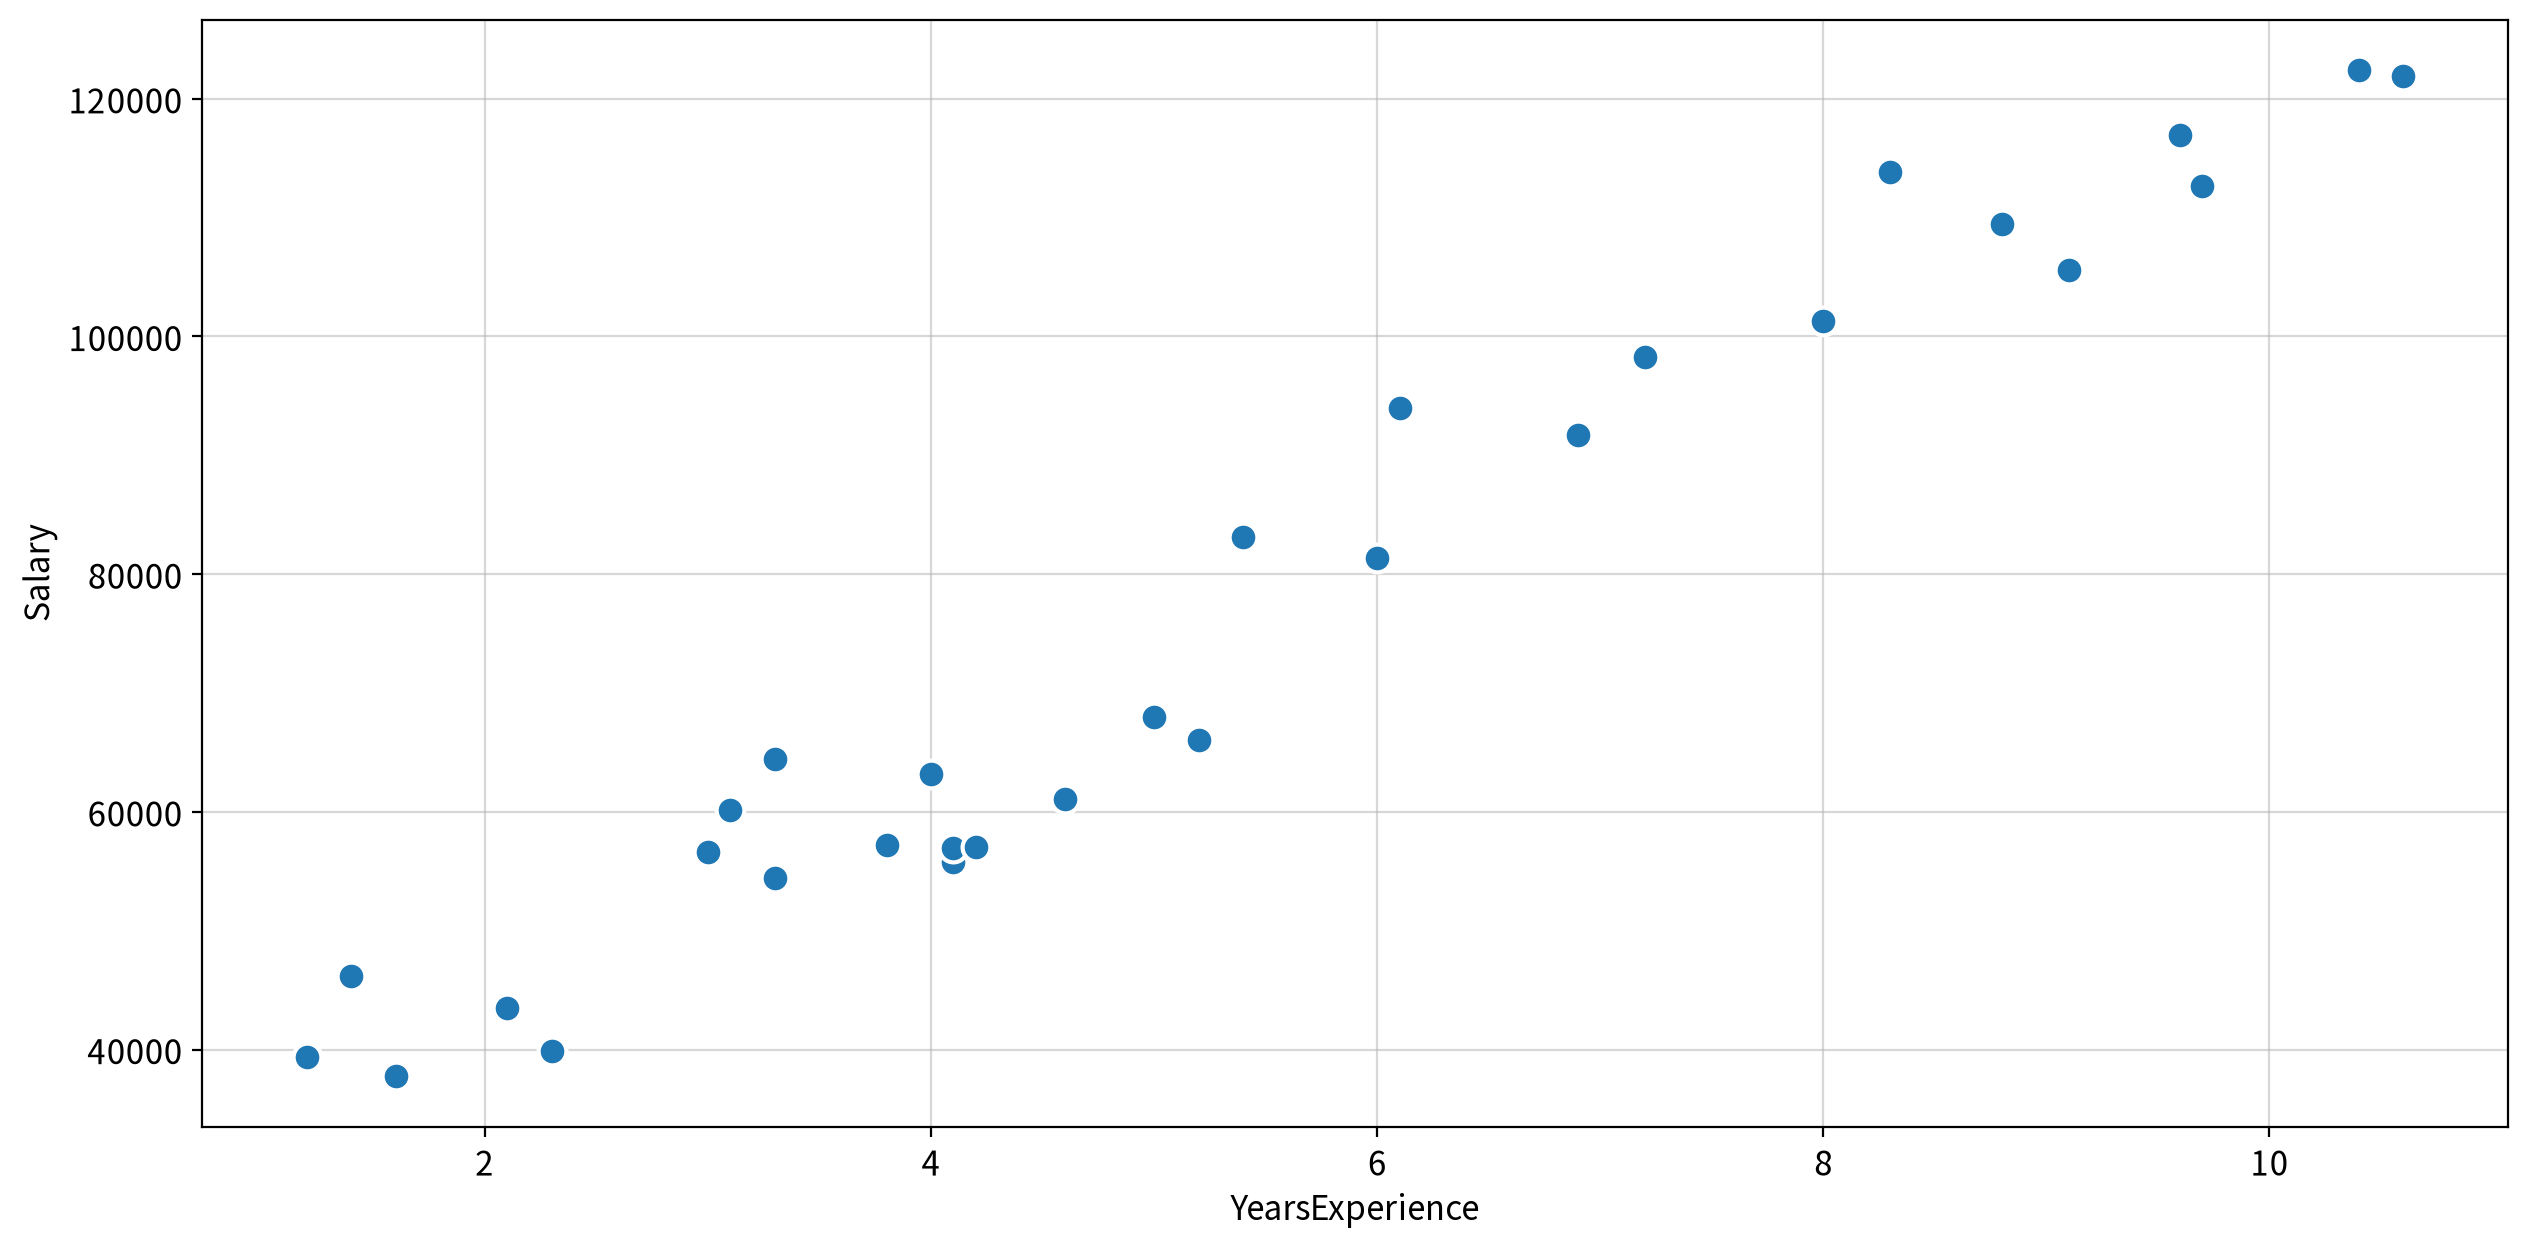

,,method,coef,strength,significant,normality,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
YearsExperience,Salary,Spearman,0.957,강함,True,True,False,True,False,False


In [7]:
my_stats.correlation(data=df, x='YearsExperience', y='Salary')

#### 상관분석 종류 스피어만 상관계수, coef 0.957

In [8]:
fit = my_ols.fit_model(df, y='Salary', summary=True)

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.14e-20
Time:                        16:38:53   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.485e+04   2306.654     

### y = 9449.9623x + 2.485e+04

In [9]:
Markdown(my_ols.report_fitness(fit))

**Note.n =30.F(1, 28) = 622.51, p < 0.001, R² = (np.float64(0.9569566641435086), 3), Adj.R² = (np.float64(0.9554194021486339), 3), Durbin-Watson = 1.648**

Salary를 종속변수로, YearsExperience(을)를 독립변수로한 단순선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(1, 28) = 622.51, p < 0.001, R² = (np.float64(0.9569566641435086), 3).

즉, YearsExperience는 Salary의 약 95.7%를 설명하는 것으로 나타났다.

In [10]:
my_ols.report_variables(fit,df)

,종속변수,독립변수,B,표준오차,β,t,유의확률,공차,VIF
0,Salary,YearsExperience,9449.962,378.755,0.978,24.950,0.000,1.000,1.000


In [11]:
New = DataFrame({"YearsExperience": [3,5,7,10]})
my_ols.predict(fit, New)

,pred
0,53198.091
1,72098.016
2,90997.940
3,119347.827


,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.083,0.974,True,귀무가설 채택 → 정규성 만족


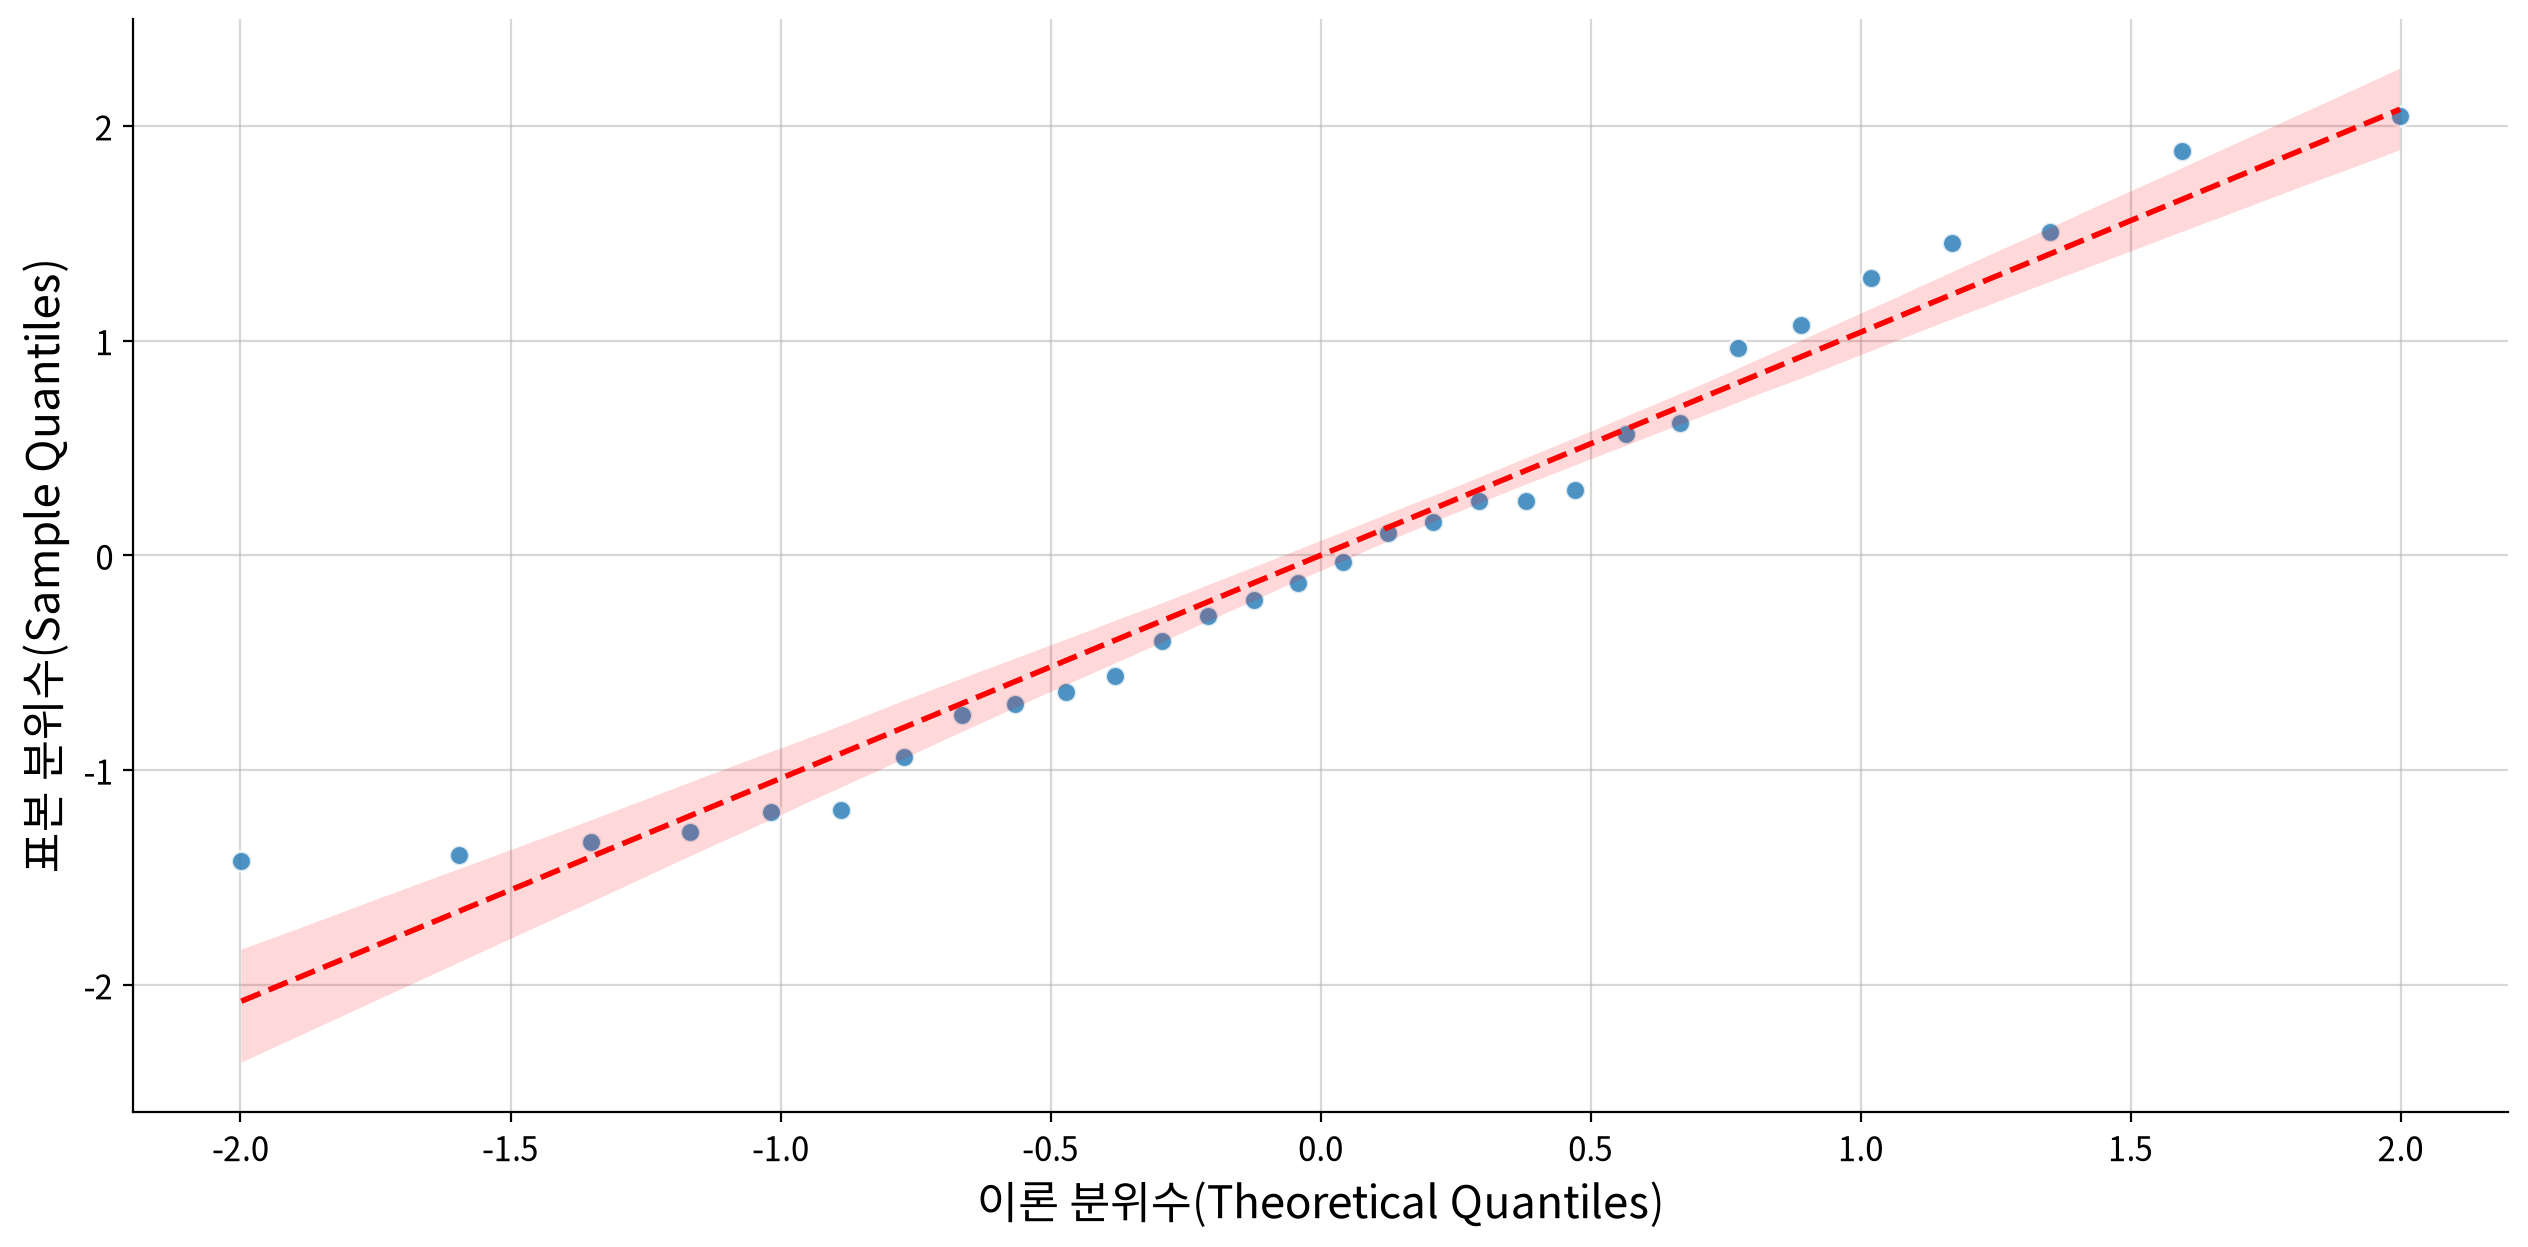

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,51~85,60.000,충족
±2√MSE,95.000,87~100,100.000,충족
±3√MSE,99.700,98~100,100.000,충족


√MSE = 5788.32 · 구간 규칙 판정: 정규성 부합


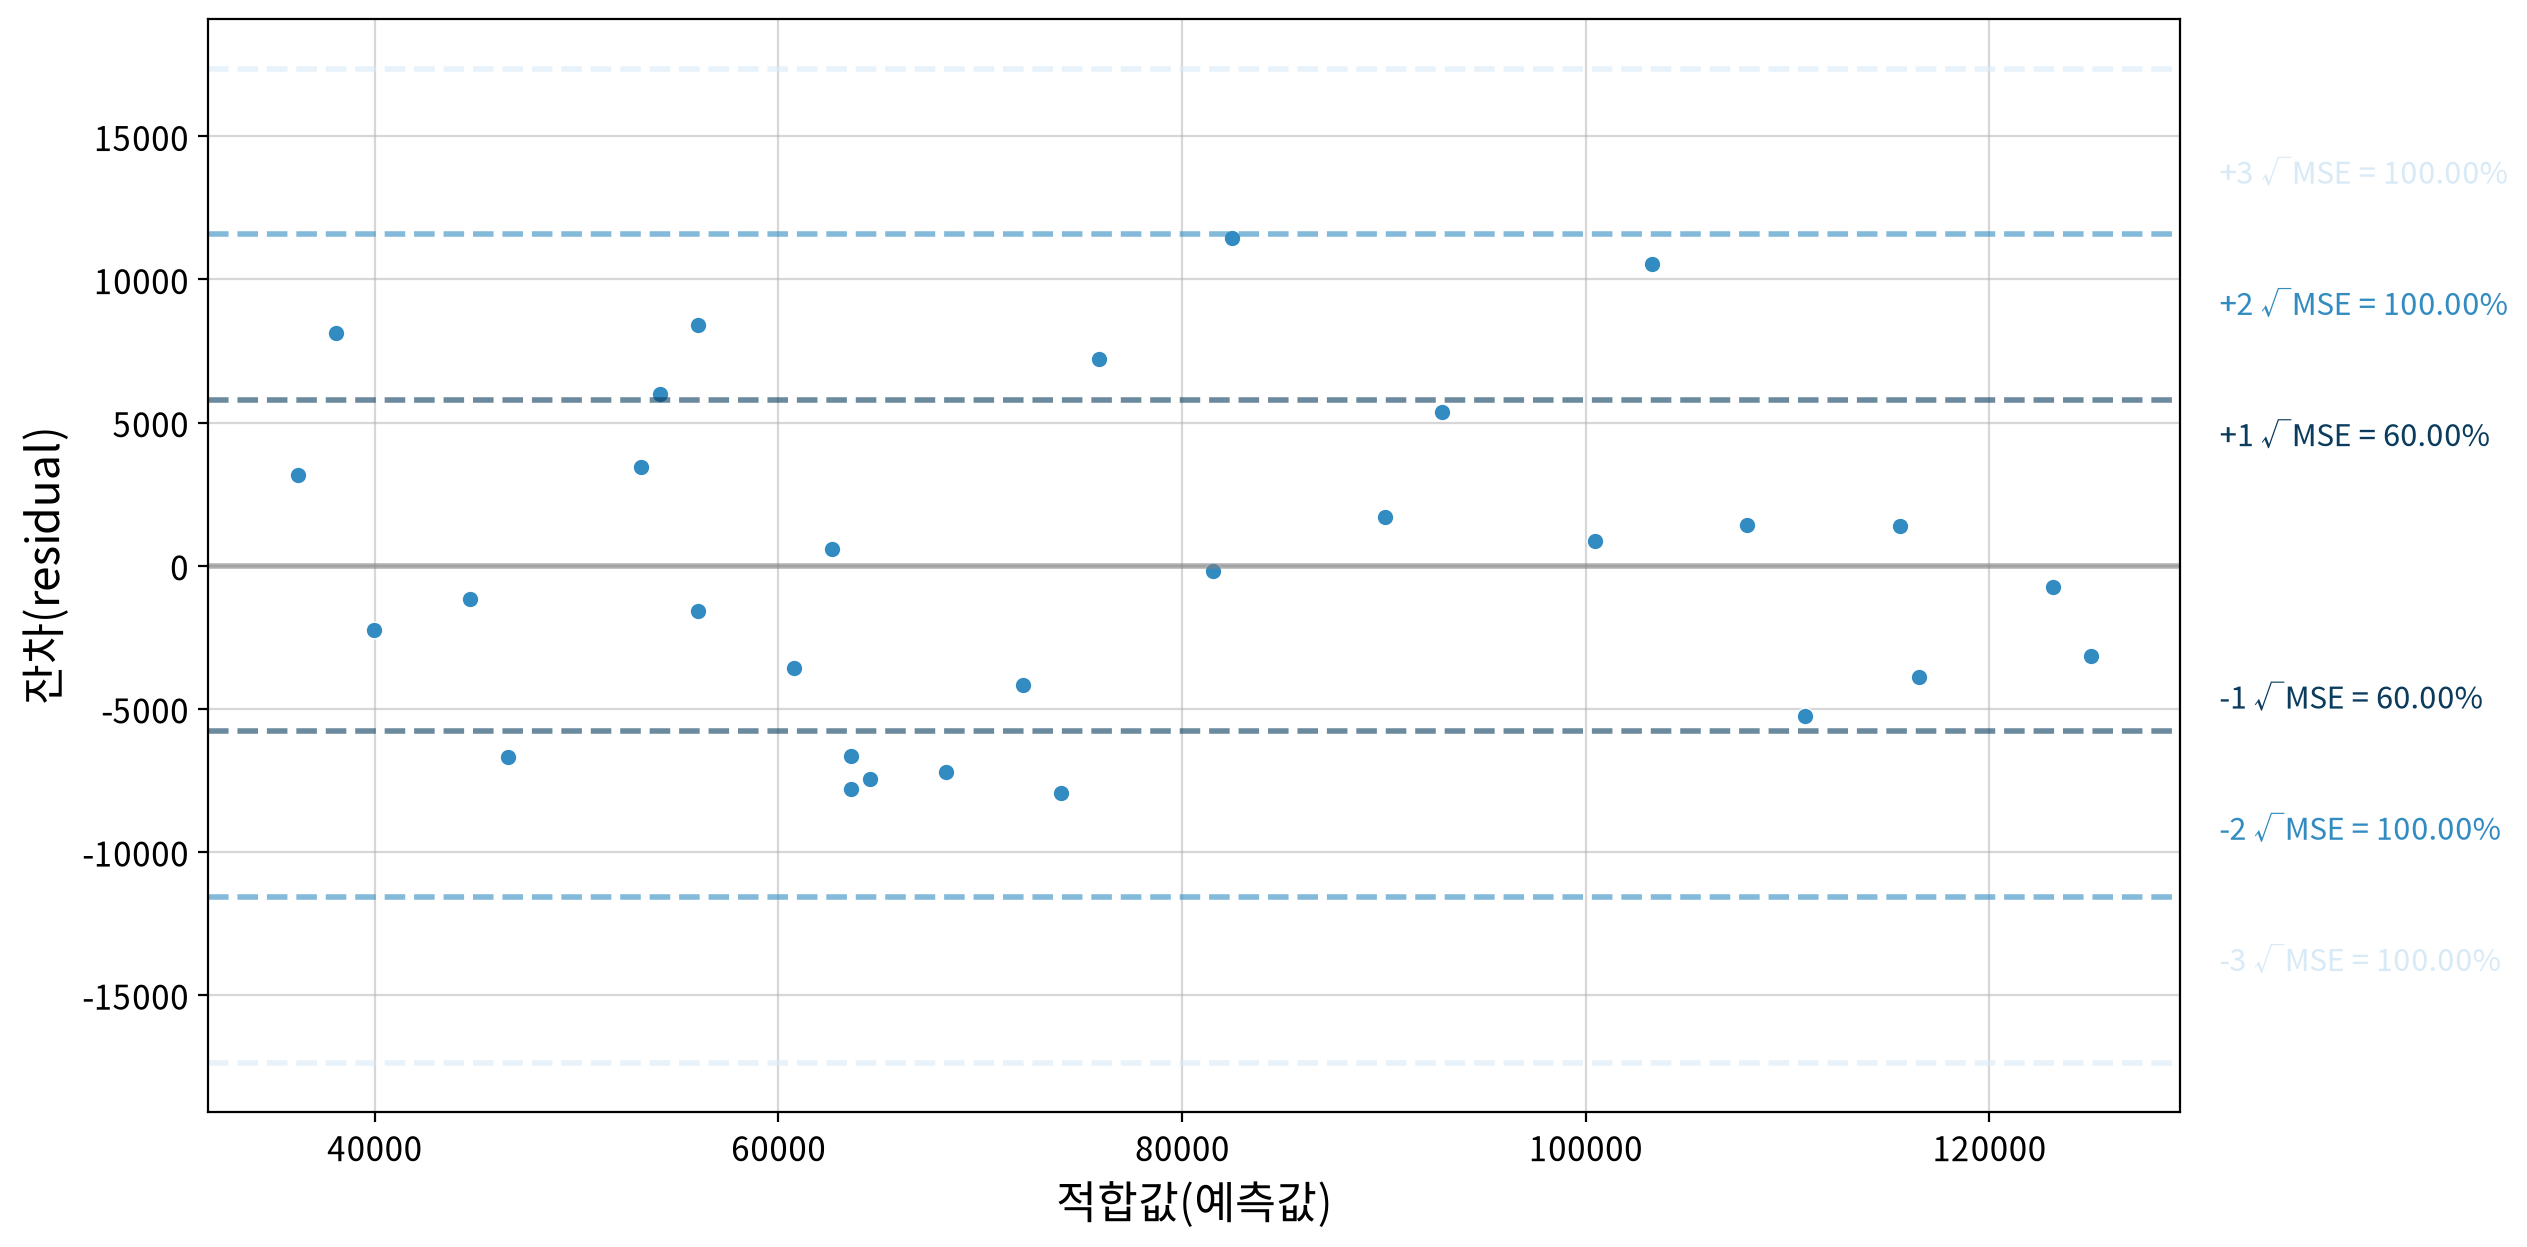

In [12]:
my_ols.test_normal(fit)

,statistic,p-value,linearity,result
Ramsey RESET,0.012,0.915,True,귀무가설 채택 -> 선형성 위배 근거 없음.


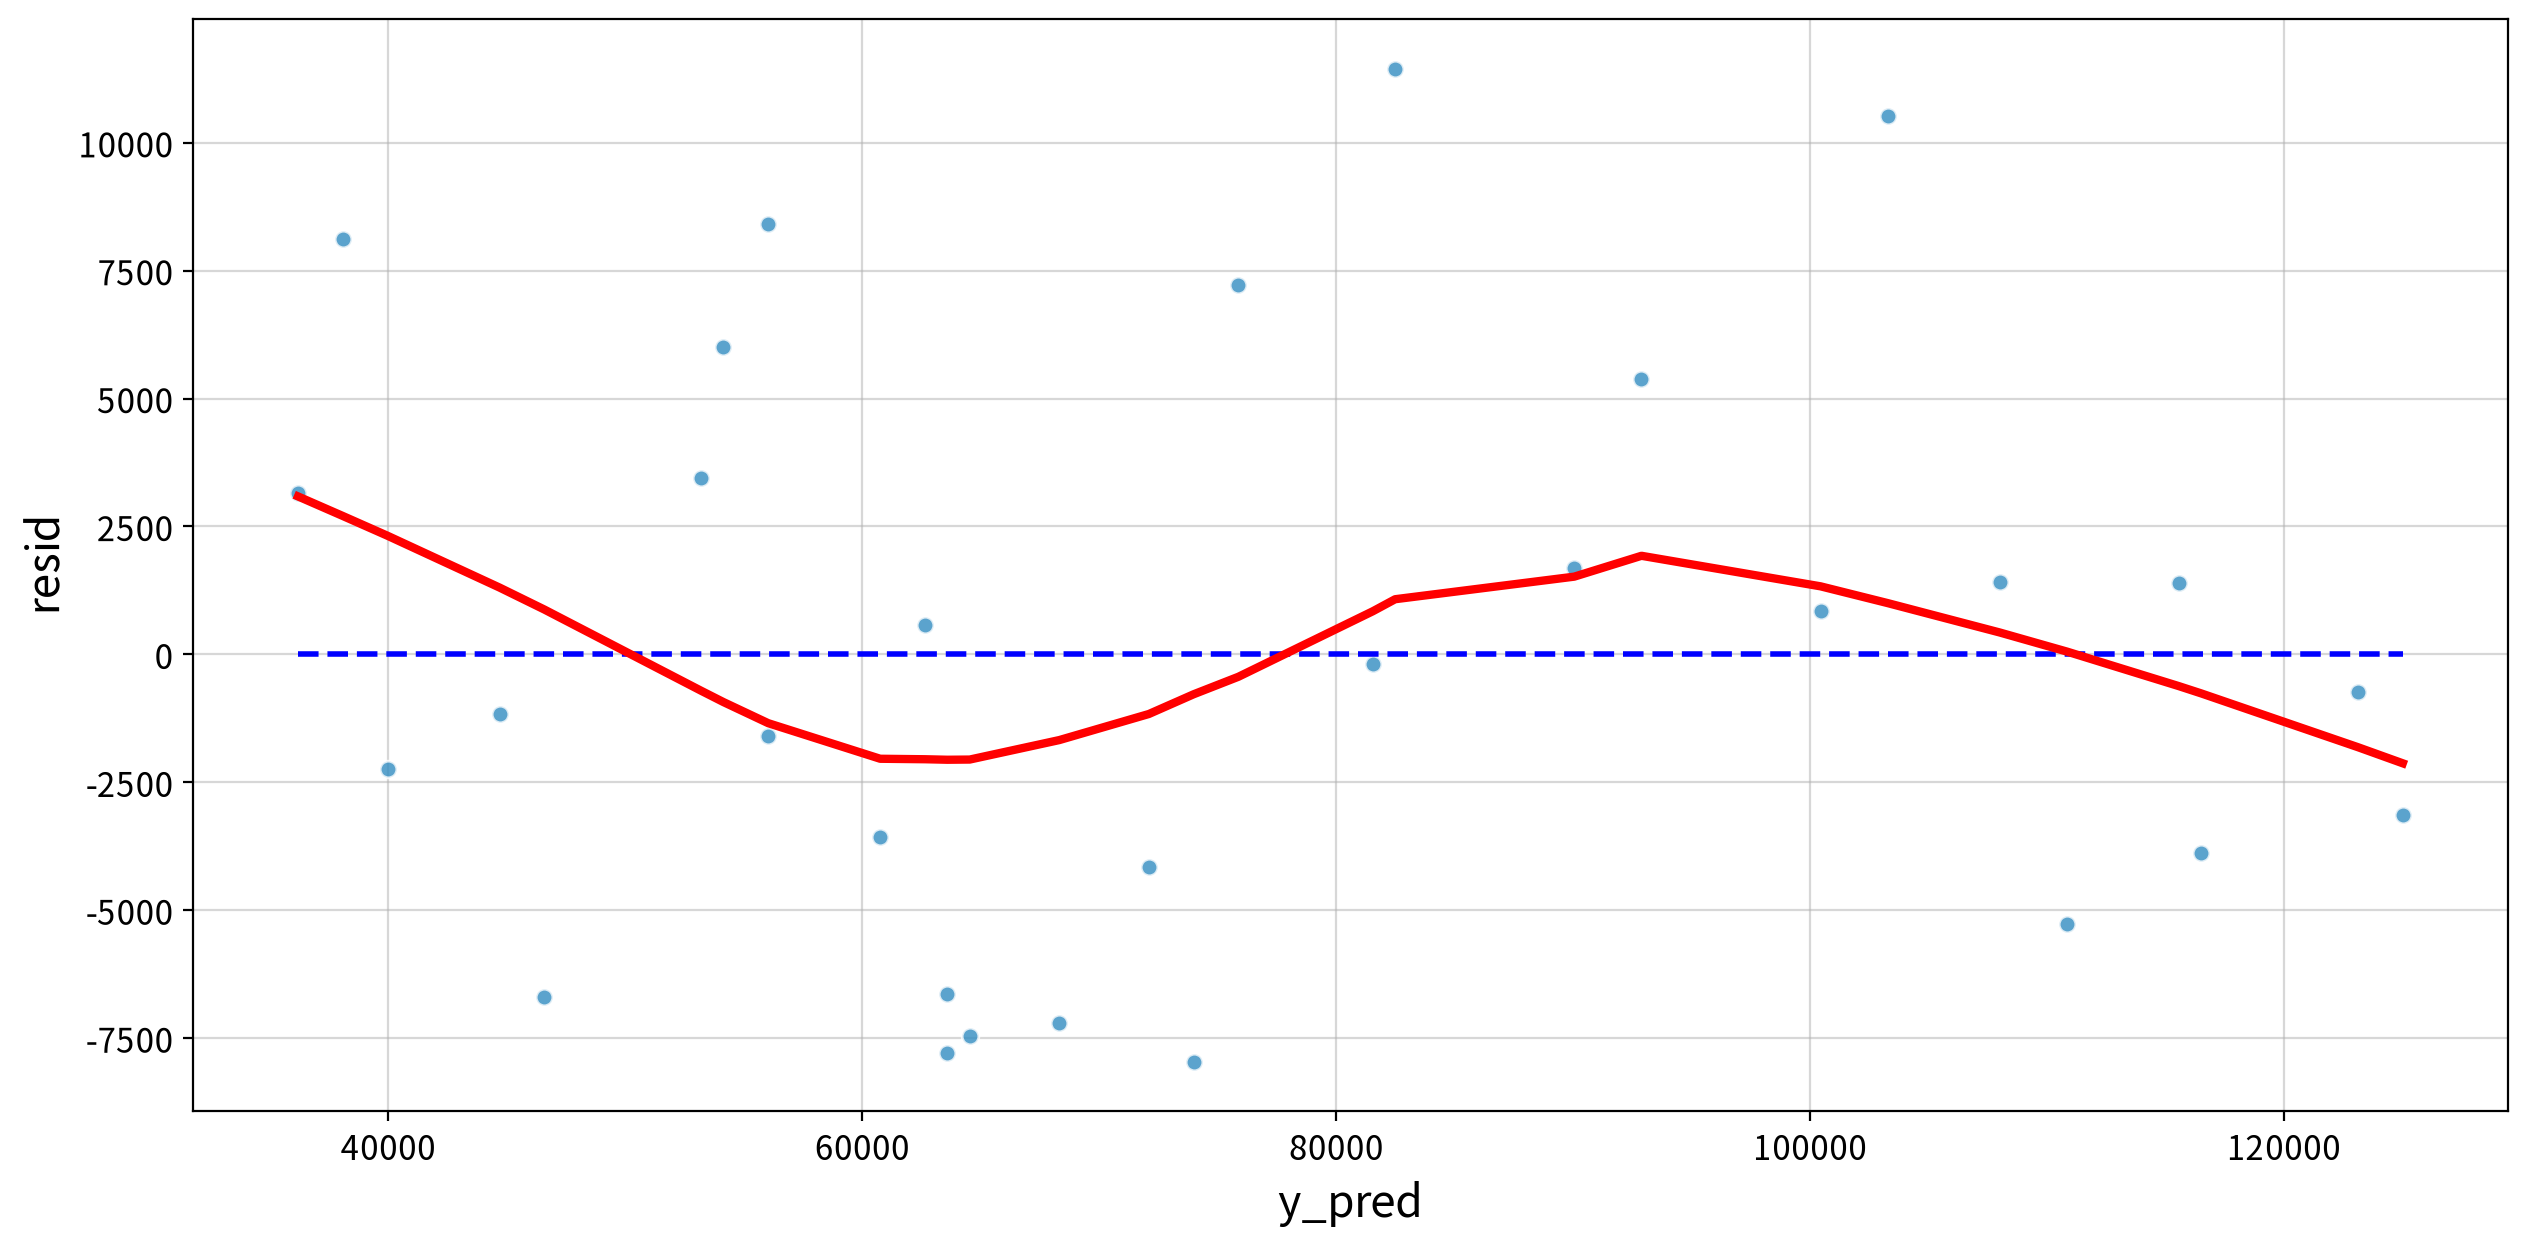

In [13]:
my_ols.test_linear(fit)

,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.083,0.974,True,귀무가설 채택 → 정규성 만족


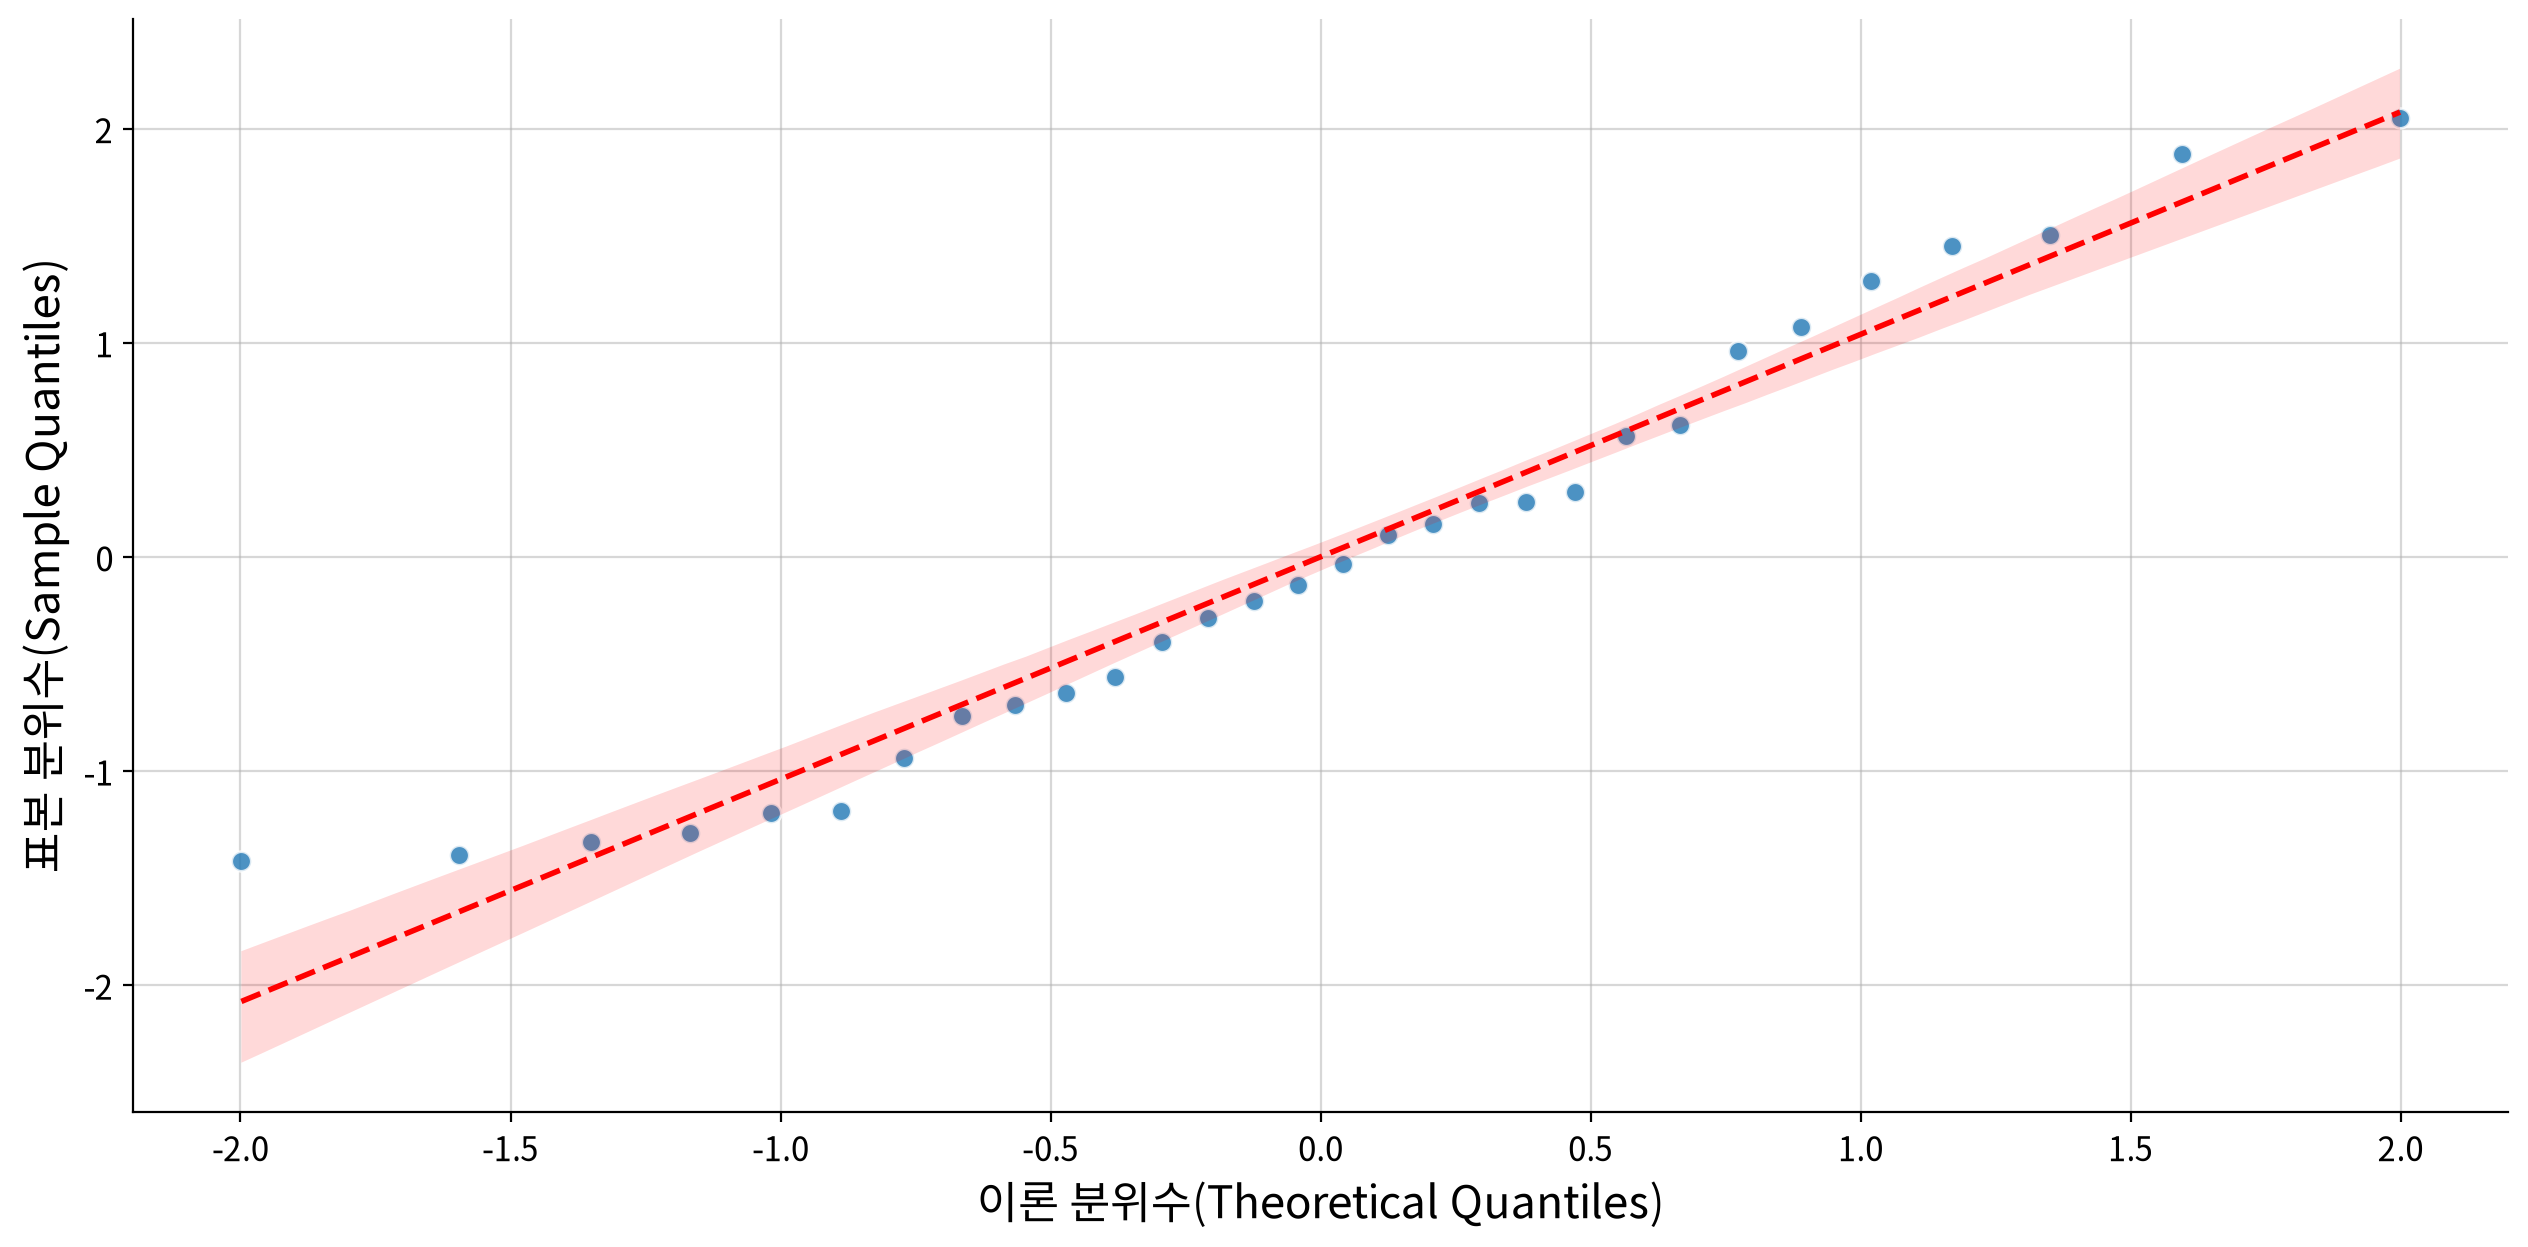

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,51~85,60.000,충족
±2√MSE,95.000,87~100,100.000,충족
±3√MSE,99.700,98~100,100.000,충족


√MSE = 5788.32 · 구간 규칙 판정: 정규성 부합


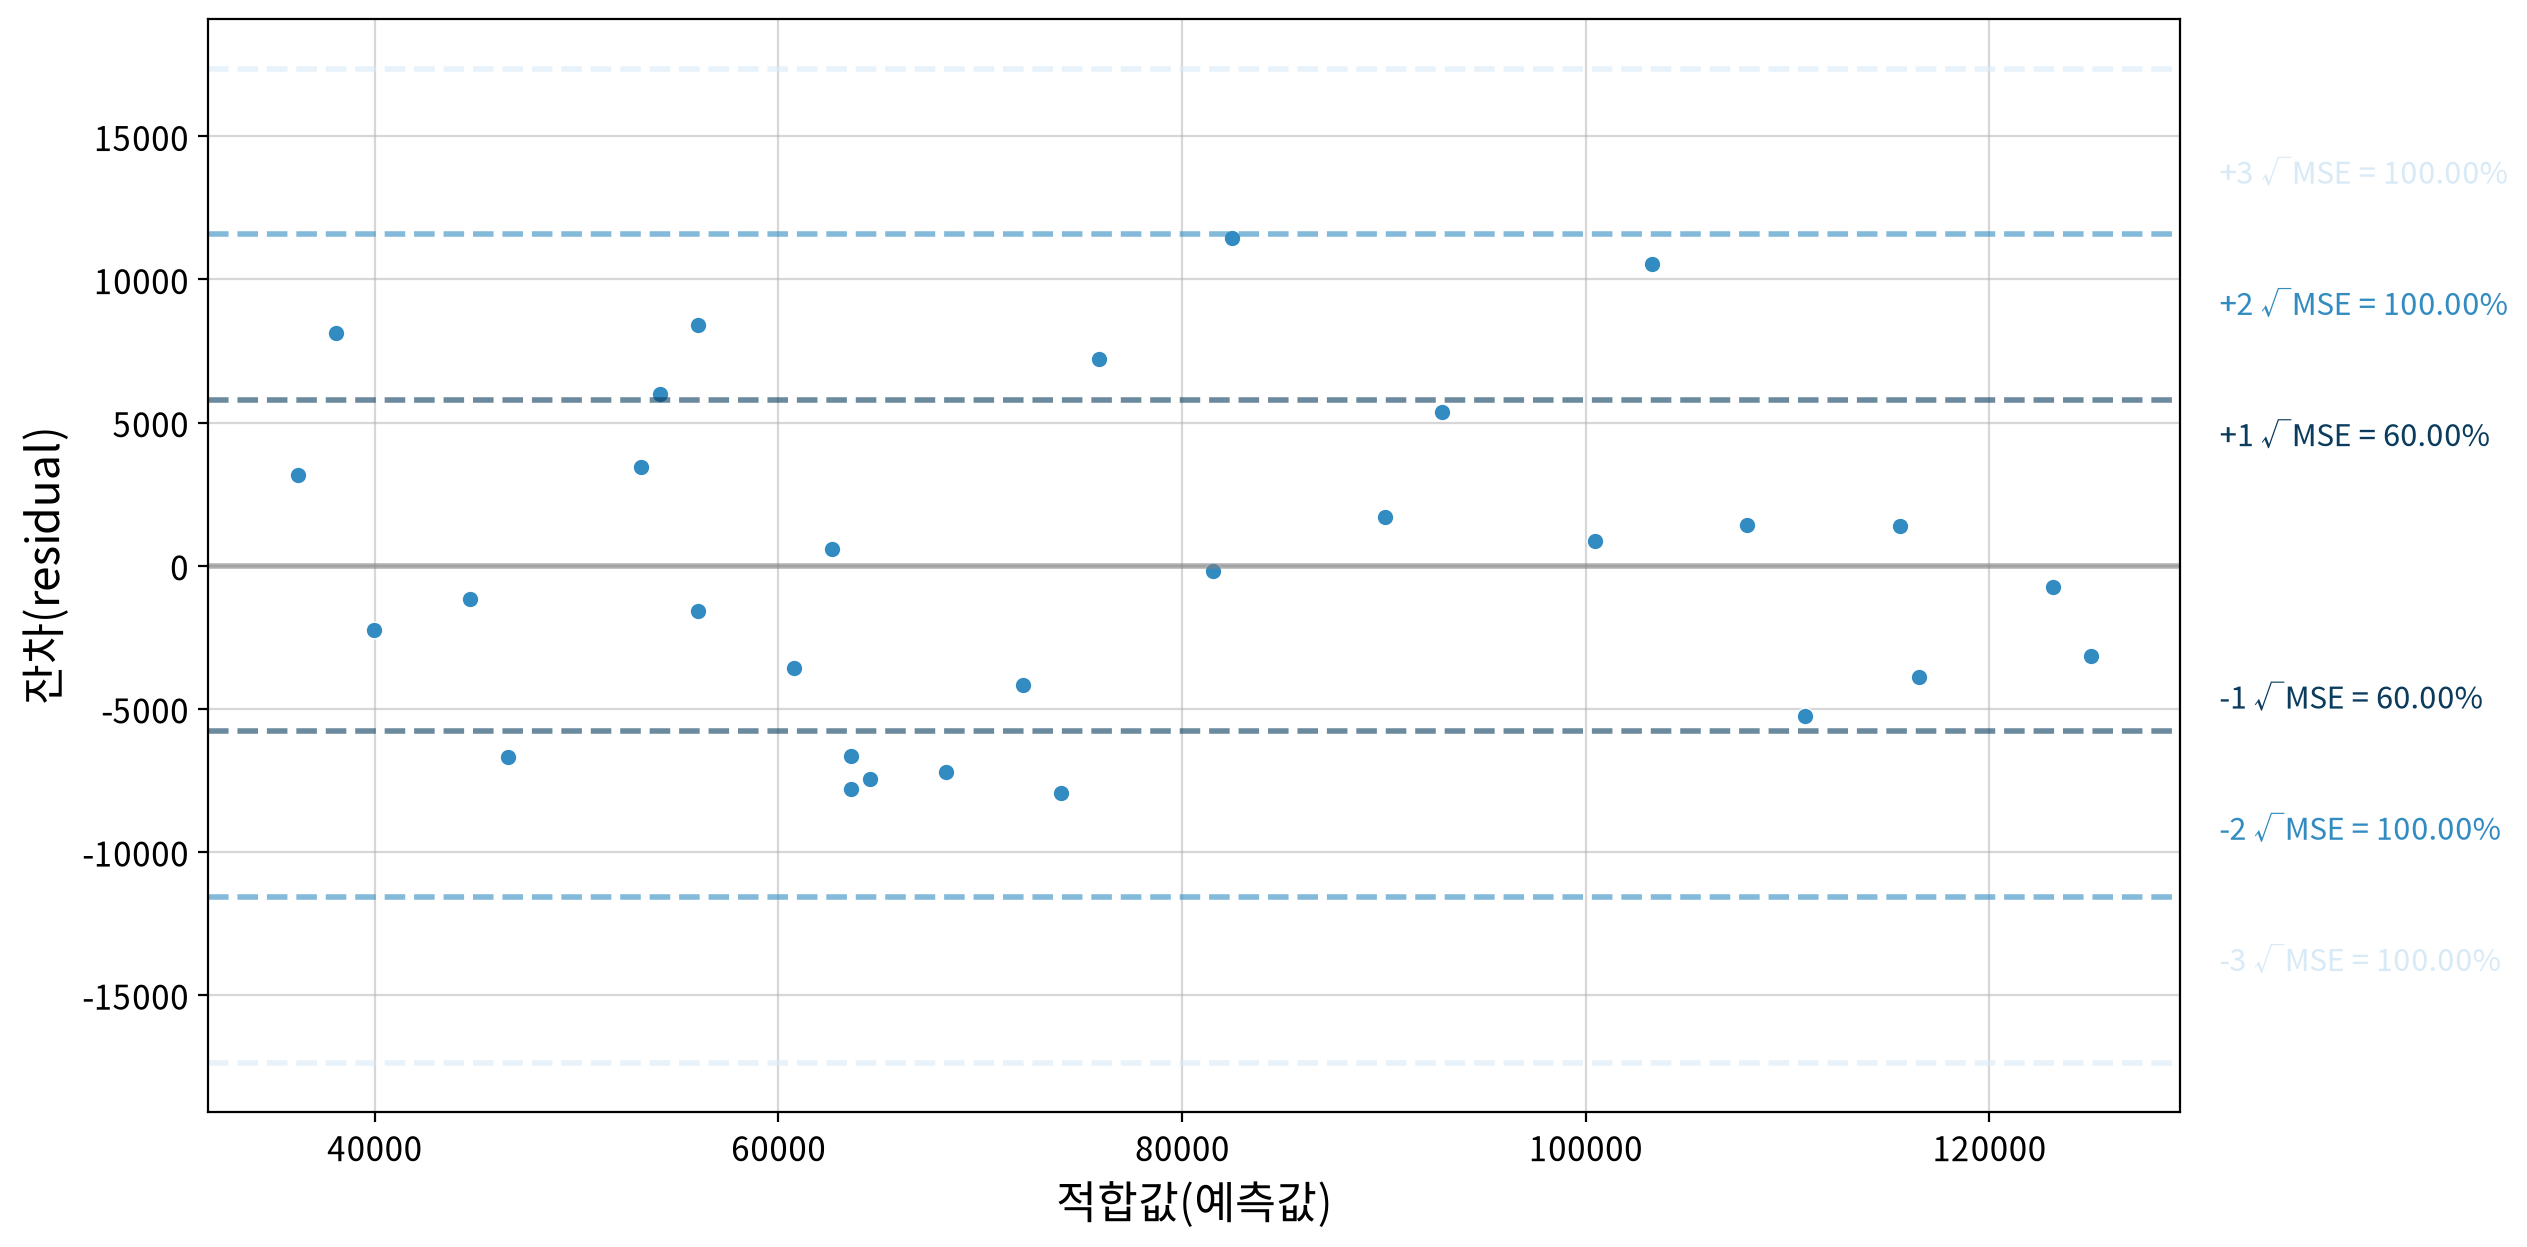

In [14]:
my_ols.test_normal(fit)

In [15]:
my_ols.test_equalvar(fit)

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Bruesch-Pagan,0.399,0.528,0.378,0.544,True,귀무가설 채택 → 등분산성 만족


In [16]:
my_ols.test_independent(fit)

,statistic,independence,result
Durbin-Watsopn,1.648,True,독립성 만족
